In this notebook, I initialize an AKLT chain, make spin measurements, and evolve approximately by the AKLT Hamiltonian by trotterizing. 

In [1]:
import numpy as np
from numpy.linalg import matrix_power
from numpy.linalg import eigh
from scipy.special import factorial
from scipy.sparse.linalg import expm_multiply
import functools as ft


from itertools import product

from qiskit import QuantumCircuit, transpiler, QuantumRegister, ClassicalRegister, AncillaRegister, transpile
from qiskit.circuit import Parameter
from qiskit.quantum_info import SparsePauliOp, Statevector
from qiskit.circuit.library import PauliEvolutionGate
from qiskit.circuit.classical import expr
from qiskit.transpiler.preset_passmanagers import generate_preset_pass_manager
from qiskit.synthesis import SuzukiTrotter

from qiskit_aer import AerSimulator


Initialize the MPS matrices and Hilbert space basis

In [3]:
A_plus = np.sqrt(2/3) * np.array([[0,1],[0,0]],dtype= complex)
A_zero = - np.sqrt(1/3) * np.array([[1,0],[0,-1]], dtype= complex)
A_minus = - np.sqrt(2/3) * np.array([[0,0],[1,0]],dtype= complex)

A = {
    "+" : A_plus,
    "0" : A_zero,
    "-" : A_minus
}

triplet_basis = {
    "+" : np.array([1,0,0,0], dtype =complex),
    "0" : 1/np.sqrt(2) * np.array([0,1,1,0],dtype= complex) ,
    "-" : np.array([0,0,0,1], dtype =complex)
}


Build N qubit periodic chain statevector

In [4]:
def AKLT_MPS(num_sites, measure):   #measure is a string which takes options {"+", "0", "-", "gs"} and indicates what initial projective state we prepare.
                                    # "gs" means we prepare the ground state, while the other options mean we prepare a state where the first site is projected into the corresponding triplet state.

    measure_set = ["+", "0", "-", "gs"]
    if measure not in measure_set:
        raise ValueError("Invalid measure value. Please choose from {'+', '0', '-', 'gs'}.")


    num_qubits = num_sites*2
    psi = np.zeros(2** num_qubits, dtype= complex)
    coef_squar_total = 0


    state_init = [i for i in product(["+","0","-"], repeat = num_sites) if i[num_sites-1] == measure or measure == "gs"] #generate all possible states of the chain consistent with the initial projection. If measure = "gs" then we include all states.

    for s in  state_init:
        
        # calculate MPS coefficient (trace uses perioic boundary conditions. 
        # To implement open boundary conditions find inner product of chain of matrices w.r.t. 
        # vL = [1,0] and vR = [0,1])
        MPS_array = [A[i] for i in s]
        coeff_matrix = np.identity(2, dtype= complex)
        for e in MPS_array:
            coeff_matrix @= e
        coeff = np.trace(coeff_matrix)

        coef_squar_total += coeff **2

        #construct the state from Kronecker producs
        State_array = [triplet_basis[i] for i in s]
        local_state = ft.reduce(np.kron, State_array)

        psi += (coeff ) * local_state

    #normalize
    psi = psi/np.sqrt(coef_squar_total)
    return psi



Create the circuit. The number of qubits needed to initialize and evolve the AKLT system is twice the number of sites, but measurement of the spin-1 sector without projecting into the spin-0 sector will require two additional ancilla qubits. Additionally, we will need 4 classical bits to record the first and second measurements of the ancillas.

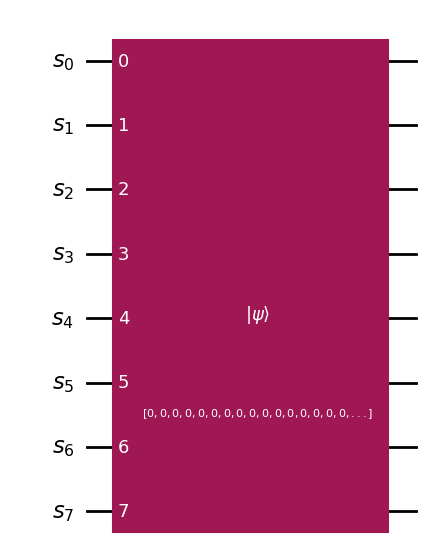

In [5]:
num_sites = 4
psi = AKLT_MPS(num_sites, "gs")
num_qubits = num_sites * 2
state_qubits = QuantumRegister(num_qubits, "s")
ancilla_qubits = AncillaRegister(2, "a")
classical_bits = ClassicalRegister(4, "c")
qc = QuantumCircuit(state_qubits , ancilla_qubits, classical_bits)
qc.initialize(psi, range(num_qubits))
sv = Statevector(psi)

qc.draw(output="mpl",  idle_wires= False, style ="iqp")

The first quantity which is useful to us is $C(t) =  \langle \frac{1}{2}\{S^z_n( 0), S^z_n(t)\}\rangle $. This is the quantity which is used in Barry and Yuntao's paper but it is only strictly relevant for dichotomic systems. Nonetheless, we will want to calculate it because it is easy and we will want to see how good of an approximator it is. 

Going forward however, if we calculate the same quantity (S10 in their SM) for a trichotomic system like $S^z$, then we get the slightly messier

$C(t) = \langle  S^z(0) \frac{1}{2}\{S^z(t) , S^z(0) \}  S^z(0)  \rangle$.

This uses the projection operator $\Pi(q) = (1 - q^2) + \frac{1}{2}q Q +(\frac{3}{2} q^2 -1 ) Q^2$

Construct the measurement operator for $S_n^z$ of the nth spin-1 site corresponding to $S_n^z = \frac{1}{2}(\sigma^z_{2n} + \sigma^z_{2n+1})$, then construct the operator $\vec S_n \cdot \vec S_{n+1} =\frac{1}{4} \sum_i (\sigma^i_{2n}\sigma^i_{2n+2} + \sigma^i_{2n}\sigma^i_{2n+3} + \sigma^i_{2n+1}\sigma^i_{2n+2} + \sigma^i_{2n+1}\sigma^i_{2n+3})$  where all indices are mod num_sites and $\sigma^i$ is the Pauli matrix and not the spin-1/2 operator.

Finally, the Hamiltonian, which is 

$\hat H = \sum_{j} \vec S_j \cdot \vec S_{j+1}+ \frac{1}{3} (\vec S_j \cdot \vec S_{j+1})^2$

In [23]:
def shift_string(pauli_string, shift):
    """Shifts a Pauli string by n places (rotates right), wrapping around."""
    shift = -shift % len(pauli_string)
    return pauli_string[shift:] + pauli_string[:shift]

def Sn_string_1(num_qubits, n_site, axis ):
    return "I" *n_site*2  + axis +"I" + "I"*(num_qubits-2 * n_site-2)
def Sn_string_2(num_qubits, n_site, axis):
    return "I" *n_site*2  + "I" + axis + "I"*(num_qubits-2 * n_site-2)
def Sn(num_qubits, n_site, axis): #returns spin-1 evaluation of site n_site along the 'axis' \in ["X","Y","Z"]
    return SparsePauliOp.from_list([(Sn_string_1(num_qubits, n_site, axis),0.5),(Sn_string_2(num_qubits, n_site, axis),0.5)])

def SSn_string_n1_n2(num_qubits, qbit1, dist, axis ): #creates the string compatable with SparsePauliOp.from_list for sigma sigma operators 
    #with the first sigma at qbit1 and the second sigma at qbit1 + dist
    if dist ==0:
        Sn1n2 = 'I' * num_qubits
    
    Sn1n2 = shift_string(axis+"I"*(dist-1) +axis +"I"* (num_qubits-dist-1) , qbit1)
    return Sn1n2

def SSn(num_qubits, n_site): #generates the sparse Pauli operator for the S dot S term between sites n_site and n_site + 1
    
    return SparsePauliOp.from_list([(SSn_string_n1_n2(num_qubits,n_site*2+k,j-k,a),0.25) for a in ["X","Y","Z"] for k in range(2)  for j in range(2,4)  ] )

def Hamiltonian_even(num_qubits): 
    """Operators which connect only bonds which start with even site index"""

    num_sites = num_qubits//2

    if num_sites % 2 == 0:
        num_even = num_sites//2
    else:
        num_even = num_sites//2 + 1
    
    SS = SparsePauliOp.from_list([(SSn_string_n1_n2(num_qubits,i*4+k,j-k,a) ,0.25)
                                    for i in range(num_even) for j in range(2,4) for a in ["X","Y","Z"] for k in range(2) ] )
    
    SSSS = SparsePauliOp.from_list([("I"*num_qubits, 0.0)])

    for i in range(num_even ):
    
        SSSS += SSn(num_qubits, i*2).dot(SSn(num_qubits, i*2))
    
    identity = SparsePauliOp.from_list([("I"*num_qubits, 1.0)])
        
    return (1.0 * SS + 1.0/3.0 *SSSS + 2.0 * num_even /3.0 * identity  ).simplify()

def Hamiltonian_odd(num_qubits): 
    """Operators which connect only bonds which start with odd site index"""

    num_sites = num_qubits//2
    num_odd = num_sites//2 

    SS = SparsePauliOp.from_list([(SSn_string_n1_n2(num_qubits,(i*2 +1)*2+k,j-k,a) ,0.25)
                                    for i in range(num_odd) for j in range(2,4) for a in ["X","Y","Z"] for k in range(2) ] )
    
    SSSS = SparsePauliOp.from_list([("I"*num_qubits, 0.0)])

    for i in range(num_odd ):
    
        SSSS += SSn(num_qubits, i*2+1).dot(SSn(num_qubits, i*2 +1))
    
    identity = SparsePauliOp.from_list([("I"*num_qubits, 1.0)])
        
    return (1.0 * SS + 1.0/3.0 *SSSS + 2.0 * num_odd /3.0 * identity  ).simplify()

def Hamiltonian(num_qubits):
   return  Hamiltonian_even(num_qubits) + Hamiltonian_odd(num_qubits)

def bond(): #generates the S dot S term for a single bond between two sites, compatable with PauliEvolutionGate
    SS = SparsePauliOp.from_list([(SSn_string_n1_n2(4,k,j-k,a),0.25) for a in ["X","Y","Z"] for k in range(2)  for j in range(2,4)  ] )
    return (SS + 1/3 *SS.dot(SS) + 2/3 * SparsePauliOp.from_list([("I"*4, 1.0)])).simplify()

def spin_string(num_sites, end_string ):
    '''Creates the spin string perator as a Sparse Pauli object'''
    num_qubits = num_sites *2
    end_1 = Sn(num_qubits, 0 , 'Z' )
    end_2 = Sn(num_qubits, end_string , 'Z' )
    bulk = SparsePauliOp.from_list([('I' * num_qubits, 1)])

    for i in range(1, end_string):
        bulk @=  SparsePauliOp.from_list([(Sn_string_1(num_qubits-1, i, 'ZZ'), -1)])   

    return  end_1 @ bulk @ end_2 



We now have to evolve the wavefunction. This will be done using Qiskit's native gate which trotterizes an input operator for one time step. This is why I separated the Hamiltonian into odd and even sites because (if num_sites is even) all even bonds commute with each other and all odd bonds commute with each other. This reduces the Trotter error. Additionally, we can mitigate error by using the Suzuki method for Trotterizing wherein we implement the second order technique where instead of $\epsilon \propto \mathcal O(\delta t^2)$ we have $\epsilon \propto \mathcal O (\delta t^3)$. This is especially important because of the $(S \cdot S)^2$ term in our Hamiltonian. 

We will also employ a method of error mitigation by time evolving as such:

$U_e(\delta t/2) U_o(\delta t) U_e(\delta t)U_o(\delta t)... U_o(\delta t)U_e(\delta t/2)$

In [8]:

def gate_even(qc, num_sites, delta):
    """Returns the Trotterized time evolution circuit element for the even bonds."""
    if num_sites % 2 == 0:
        num_even = num_sites//2
    else:
        return "error - even number of sites required for even bond evolution"

    for i in range(num_even):
        qc.append(PauliEvolutionGate(bond(), delta , 
                                     synthesis=SuzukiTrotter(order = 2, reps = 2),label = "$\\exp\\{- i H_e $("+ str(delta) + ")\\}"), range(4 * i, 4 * i + 4))

def gate_odd(qc, num_sites, delta):
    """Returns the Trotterized time evolution circuit element for the odd bonds."""
    if num_sites % 2 == 0:
        num_odd = num_sites//2
    else:
        return "error - even number of sites required for odd bond evolution"

    for i in range(num_odd):
        qc.append(PauliEvolutionGate(bond(), delta , 
                                     synthesis=SuzukiTrotter(order = 2, reps = 2), label = "$\\exp\\{- i H_o $("+ str(delta) + ")\\}"), [(4 * i +2+j )% (2 * num_sites) for j in range(4)] )

def trotter_gate(qc, num_sites , t):
    """Returns the Trotterized time evolution with error ~ O(t^3) ."""


    gate_even(qc, num_sites, t/2)
    gate_odd(qc, num_sites, t)
    gate_even(qc, num_sites, t/2)

def second_trotter_gate(qc, delta ):
    """Returns the second Trotterized time evolution with error ~ O(t^2 delta) which is better than the method outlined above
    , but is less efficient and cannot be used for non-integer t."""
    num_steps = qc.num_steps
    num_sites = qc.num_sites
    
    gate_even(qc, num_sites, delta/2)
    for i in range(num_steps-1):
        gate_odd(qc, num_sites, delta)
        gate_even(qc, num_sites, delta)

    gate_odd(qc, num_sites, delta)
    gate_even(qc, num_sites, delta/2)



We also need to construct the measurement circuit components. What this does is couple a pair of ancilla qubits to the spin to be measured. By measuring the ancillas, we can determine the total spin of the two qubits without projecting into the spin-0 sector. 

In [9]:
def measure_Sz(qc, n_site,  instance): 
    
    n_site = 0 #location of one end of the string
    for reg in qc.qregs:  #Define the ancilla register
        if reg.name == "a":
            ancilla_qubits = reg
            break
    
    for reg in qc.cregs:    #Define the classical register
        if reg.name == "c":
            classical_bits = reg
            break
    
    qc.ccx(n_site*2, n_site*2 +1, ancilla_qubits[1]) # measures the product of the two qubits encoding the spin-1 site
    
    qc.cx(n_site*2, ancilla_qubits[0])
    qc.cx(n_site*2 +1, ancilla_qubits[0]) # measures the parity of the two qubits encoding the spin-1 site

    qc.measure(ancilla_qubits[1], classical_bits[instance * 2 + 1])
    qc.measure(ancilla_qubits[0], classical_bits[instance * 2])

    qc.cx(n_site*2, ancilla_qubits[0])
    qc.cx(n_site*2 +1, ancilla_qubits[0]) #This returns the ancilla to the |0> state so that it can be reused for the next measurement without needing to reset it.
    qc.ccx(n_site*2, n_site*2 +1, ancilla_qubits[1]) # This returns the ancilla to the |0> state so that it can be reused for the next measurement without needing to reset it.

def SzSz_correlation(all_counts):
    """Calculates the SzSz correlation from the counts list."""
    num_shots = 3 * sum(all_counts["0"][0].values()) # assumes all counts have the same number of shots, which should be the case if they were all generated from the same circuit with the same number of shots.

    
    return [(all_counts.get("+",0)[t].get("+",0)+ all_counts.get("-",0)[t].get("-",0)
      - all_counts.get("-",0)[t].get("+",0)- all_counts.get("+",0)[t].get("-",0))/num_shots   for t in range(len(all_counts["0"]))]


def Sz2Sz2_correlation(all_counts):
    """Calculates the SzSz correlation from the counts list."""
    num_shots = 3 * sum(all_counts["-"][0].values()) # assumes all counts have the same number of shots, which should be the case if they were all generated from the same circuit with the same number of shots.

    
    return [(all_counts.get("+",0)[t].get("+",0))/num_shots   for t in range(len(all_counts["-"]))]







Now that we have everything together for the simplest version of the Legget-Garg AKLT experiment, we can construct the circuit with measurements in order to construct the correlation function. In theory, this should be doable on native hardware for small number of sites. 

In [10]:

def AKLT_initialize(num_qubits, num_ancilla, num_classical):
    '''Builds a circuit appropriate for a num_sites site AKLT chain.'''
    
    state_qubits = QuantumRegister(num_qubits, "s")
    ancilla_qubits = AncillaRegister(num_ancilla, "a")
    classical_bits = ClassicalRegister(num_classical, "c")
    qc = QuantumCircuit(state_qubits , ancilla_qubits, classical_bits)
    return qc

def AKLT_sim_projective_Sz(num_sites, t, delta):
    """Runs the simulation for the AKLT model and returns the SzSz correlations."""
    if num_sites % 2 != 0 or num_sites < 4:
        return "Error: num_sites must be an even integer greater than or equal to 4."
    
    num_qubits = num_sites * 2
    num_steps =int(t/delta)                     #The trotter steps for the second trotterized function must be globally defined
    num_shots = 1000                            #hard code this for now
    all_counts = {"+": [{'+': num_shots, '0': 0, '-': 0}], "0": [{'+': 0, '0': num_shots, '-': 0}], "-": [{'+': 0, '0': 0, '-': num_shots}]}

    for measure in ["+", "0", "-"]:             #We take advantage of the fact that the initial measurement of the first site has probabilities
                                                #1/3 for each outcome to decrease random noise by preparing these states explicitly, then running

        psi = AKLT_MPS(num_sites, measure)
        qc  = AKLT_initialize(num_qubits, 2,2)
        qc.initialize(psi, range(num_qubits))       #initiialize circuit with AKLT ground state
   
        trotter_gate(qc, num_sites, delta)         #First leg of the circuit
        qc.save_statevector() 

        backend = AerSimulator(method = "statevector") #run the initial circuit
        qc = transpile(qc, backend)                
        job = backend.run(qc, shots = num_shots)
        result = job.result()

        #do a loop over time values where we:
    #1) extract the statevector from the result of the previous circuit
    #2) copy the statevector
    #3) measure the copy
    #4) evolve the original statevector by another time step

        for step in range( num_steps):
            state = result.get_statevector()
            qc1 = AKLT_initialize(num_qubits, 2,2)
            qc1.initialize(state, range(num_qubits+2))
            qc1.measure([0,1], [0,1])    #measure copy

            qc1 = transpile(qc1, backend) 
            job1 = backend.run(qc1, shots = num_shots)
            result1 = job1.result().get_counts()
            spin_1_format = {"+": result1.get("00",0), "0": result1.get("10",0) + result1.get("01",0), "-" : result1.get("11",0)}
            all_counts.get(measure).append(spin_1_format)

            qc = AKLT_initialize(num_qubits, 2, 2)
            qc.initialize(state, range(num_qubits+2))
            trotter_gate(qc, num_sites, delta)     #evolve original state by time step
            qc.save_statevector() 

            qc = transpile(qc, backend)
            job2 = backend.run(qc, shots = num_shots)
            result = job2.result()


    return all_counts

#all_counts = AKLT_sim_run(num_sites = 4, time = 10, delta = .1)
#print(SzSz_correlation(all_counts))

Create a measurement sequence which is dichotomic by looking at the absolute value of $S_z$, i.e. $S_z^2$

In [11]:
def AKLT_sim_projective_Sz2(num_sites, t, delta):
    """Runs the simulation for the AKLT model and returns the Sz^2 Sz^2(t) correlations."""
    if num_sites % 2 != 0 or num_sites < 4:
        return "Error: num_sites must be an even integer greater than or equal to 4."
    
    num_qubits = num_sites * 2
    num_steps =int(t/delta)                     #The trotter steps for the second trotterized function must be globally defined
    num_shots = 1000                            #hard code this for now
    all_counts = {"+": [{'+': 2 * num_shots,  '-': 0}], "-": [{'+': 0,  '-': num_shots}]}

    for measure in ["+", "0", "-"]:             #We take advantage of the fact that the initial measurement of the first site has probabilities
                                                #1/3 for the "-" = sz^2 = 0 and 2/3 for sz^2 = 1
        if measure == "0": parity = "-"
        else: parity = "+" 
        psi = AKLT_MPS(num_sites, measure)
        qc  = AKLT_initialize(num_qubits, 2,2 )
        qc.initialize(psi, range(num_qubits))       #initiialize circuit with AKLT ground state
   
        trotter_gate(qc, num_sites, delta)         #First leg of the circuit
        qc.save_statevector() 

        backend = AerSimulator(method = "statevector") #run the initial circuit
        qc = transpile(qc, backend)                
        job = backend.run(qc, shots = num_shots)
        result = job.result()

        #do a loop over time values where we:
    #1) extract the statevector from the result of the previous circuit
    #2) copy the statevector
    #3) measure the copy
    #4) evolve the original statevector by another time step

        for step in range( num_steps):
            state = result.get_statevector()
            qc1 = AKLT_initialize(num_qubits, 2, 2)
            qc1.initialize(state, range(num_qubits+2))
            qc1.measure([0,1], [0,1])    #measure copy

            qc1 = transpile(qc1, backend) 
            job1 = backend.run(qc1, shots = num_shots)
            result1 = job1.result().get_counts()
            spin_1_format = {"+": result1.get("00",0)+ result1.get("11",0), "-": result1.get("10",0) + result1.get("01",0)}
            all_counts.get(parity).append(spin_1_format)

            qc = AKLT_initialize(num_qubits, 2, 2)
            qc.initialize(state, range(num_qubits+2))
            trotter_gate(qc, num_sites, delta)     #evolve original state by time step
            qc.save_statevector() 

            qc = transpile(qc, backend)
            job2 = backend.run(qc, shots = 1)       #Because we aren't making measurements, we only run to save the statevector, only one shot is needed
            result = job2.result()


    return all_counts

#all_counts = AKLT_sim_run(num_sites = 4, time = 10, delta = .1)
#print(SzSz_correlation(all_counts))

We also need a function which calculates the weak measurement function which is 

$\langle \frac{1}{2}\{S^z(0),S^z(t)\}\rangle = \langle \frac{1}{2}\{S^z(0),\exp(i \hat H t)S^z(0) \exp(-i \hat H t)\}\rangle$

Instead of using a circuit, I will directly compute the expectation value.

In [12]:
def AKLT_sim_weakmeasure(num_sites, t, delta):
    """Runs the simulation for the AKLT model and returns the SzSz correlations."""
    if num_sites % 2 != 0 or num_sites < 4:
        return "Error: num_sites must be an even integer greater than or equal to 4."
    
    num_qubits = num_sites * 2
    num_steps =int(t/delta)                     #The trotter steps for the second trotterized function must be globally defined
    psi = AKLT_MPS(num_sites, 'gs')             #This time we use the ground state to evaluate expectations
    Ham = Hamiltonian(num_qubits).to_matrix(sparse = True)
 
    Szi =  Sn(num_qubits,0, 'Z' ).to_matrix(sparse = True)  #spin-1 z operator on site 0
    phi = Szi @ psi
    corr_list = [2/3]                                       #The initial value of <Sz^2>

    for i in range(num_steps):
        chi = expm_multiply(-1j * delta  * Ham, phi )
        xi = Szi @ chi
        expec = np.vdot(psi, xi)
        phi = chi
        corr_list.append(  float(np.real(expec)))            #the real part of <S exp(i H t) S> is equivalent to the correlation we want
                                                             #(exp(i H t) psi = psi 

    return corr_list




The correlation with the greatest chance of success is the spin string operator $S_{ij} = S_i\left( \sum_{k =i+1}^{j-1}\exp(i \pi S_k) \right)S_j$ which tracks the hidden antiferromagnetic order. 

In [ ]:
def initiate_quantum_classical_register(qc):
    ''' returns the ancilla and classical register of qc'''

    for reg in qc.qregs:  #Define the ancilla register
        if reg.name == "a":
            ancilla_qubits = reg
            break
    
    for reg in qc.cregs:    #Define the classical register
        if reg.name == "c":
            classical_bits = reg
            break

    return [ancilla_qubits, classical_bits]

def couple_string(qc, site_i,   instance): 
    '''This function couples the pair of ancila qubits at instant*2 and instance *2 +1 such that 01 = +, 00 = 0, 10 = -1'''

    n_site = 0 #location of one end of the string

    ancilla_qubits, classical_bits = initiate_quantum_classical_register(qc)

    if  n_site == site_i:
        raise ValueError("left and right sites must be different" )
    
    anc_sign = ancilla_qubits[2]
    
    qc.cx(n_site*2, ancilla_qubits[instance])
    qc.cx(n_site*2 +1, ancilla_qubits[instance]) # measures the parity of the two qubits encoding the spin-1 site at one end
    

    qc.cx(site_i *2, ancilla_qubits[instance])
    qc.cx(site_i*2 +1, ancilla_qubits[instance]) # and at the other end of the chain

    qc.ccx(site_i *2, n_site *2 +1, ancilla_qubits[instance])      #the cx gates leave ancilla = 1 for opposite parity on both sites, but we want 1 whenever any site spin is 0
    qc.ccx(site_i *2, n_site *2 , ancilla_qubits[instance])         #i.e. an or function. This set of cx and ccx accomplishes this
    qc.ccx(site_i *2+1, n_site *2 +1, ancilla_qubits[instance])
    qc.ccx(site_i *2+1, n_site *2 , ancilla_qubits[instance])

    qc.cx(n_site *2, anc_sign)                  #the sign ancilla which distinguishes between +1 and -1. Only one of each spin-1 needs to be measured because
    qc.cx(site_i *2, anc_sign)                  #this ancilla will only be measured if both of these spins have magnitude 1

    for q in range(n_site * 2 +2, 2* site_i):
        qc.cx(q, ancilla_qubits[1])             #The spin chain bulk
        
    
    
def measure_string(qc ):
    '''measures only the necessary ancillas for determining the correlation'''

    aqb, cb = initiate_quantum_classical_register(qc)
    anc_sign, cb_sign = aqb[2], cb[2]

    qc.measure(aqb[0], cb[0])
    with qc.if_test((cb[0],0)):         #if one end is not zero
        qc.measure(aqb[1], cb[1])
    with qc.if_test(expr.bit_not(expr.bit_or(cb[0], cb[1]))): #if both ends are not zero
        qc.measure(anc_sign, cb_sign)

    


def AKLT_sim_projective_string(num_sites, site_i, t, delta):
    """Runs the simulation for the AKLT model and returns the SzSz correlations."""
    if num_sites % 2 != 0 or num_sites < 4:
        return "Error: num_sites must be an even integer greater than or equal to 4."
    
    num_qubits = num_sites * 2
    num_steps =int(t/delta)  +1                 #The trotter steps for the second trotterized function must be globally defined
    num_shots = 10000                            #hard code this for now
    backend = AerSimulator(method = "statevector") #define backend 
    
    num_ancilla = 3
    num_classical = 3

    
    psi = AKLT_MPS(num_sites, "gs")
    qc  = AKLT_initialize(num_qubits, num_ancilla, num_classical)
    qc.initialize(psi, range(num_qubits))       #initiialize circuit with AKLT ground state

    couple_string(qc, site_i, 0)
    qc.save_statevector()                       #First leg of the circuit
                    
    qc = transpile(qc, backend)                    
    job = backend.run(qc, shots = 1)            #Only one shot necessary to save statevector
    result = job.result()

    all_counts = []
    for step in range(num_steps):
        state = result.get_statevector()
        qc1  = AKLT_initialize(num_qubits, num_ancilla, num_classical)
        qc1.initialize(state, range(num_qubits+ num_ancilla))   #Copy state

        couple_string(qc1, site_i, 1)           #add second measurement of spin chain
        measure_string(qc1)

        qc1 = transpile(qc1, backend)
        job = backend.run(qc1, shots = num_shots) #run simulation
        result1 = job.result().get_counts()     # {+: 000, 0: 010 + 001, - : 100}
        all_counts += [{"+": result1.get("000",0) , "0": result1.get("001",0)+result1.get("010",0), "-": result1.get("100",0)}]

        qc = AKLT_initialize(num_qubits, num_ancilla, num_classical)
        qc.initialize(state, range(num_qubits+ num_ancilla))
        trotter_gate(qc, num_sites, delta)     #evolve copied state by time step
        qc.save_statevector() 

        qc = transpile(qc, backend)
        job2 = backend.run(qc, shots = 1)   #save as new statevector
        result = job2.result()

    return all_counts
    

def spin_string_correlation(all_counts):
    """Calculates the string chain correlation from the counts list."""
    num_shots =  sum(all_counts[0].values()) #
    
    return [(all_counts[t].get("+",0) - all_counts[t].get("-",0))/num_shots   for t in range(len(all_counts))]



We can also try a dichotomic operator which encorporates a measurement of the entire system by calculating the operator $P = \prod_j \exp(i \pi  S_j)$ which counts the parity of the odd sites. This operator is essentaially what we get if we make the bulk of the string operator act on the whole chain. Unfortunately, this operator is only marginally useful because the ground state of the AKLT chain is an eigenstate of $P$.  

In [14]:
def AKLT_sim_projective_string_all(num_sites, t, delta):
    """Runs the simulation for the AKLT model and returns the SzSz correlations."""
    if num_sites % 2 != 0 or num_sites < 4:
        return "Error: num_sites must be an even integer greater than or equal to 4."
    
    num_qubits = num_sites * 2
    num_steps =int(t/delta)  +1                 #The trotter steps for the second trotterized function must be globally defined
    num_shots = 10000                            #hard code this for now
    backend = AerSimulator(method = "statevector") #define backend 
    
    num_ancilla = 2
    num_classical = 2

    
    psi = AKLT_MPS(num_sites, "gs")
    qc  = AKLT_initialize(num_qubits, num_ancilla, num_classical)
    qc.initialize(psi, range(num_qubits))       #initiialize circuit with AKLT ground state

    anc_sign, cl_sign = initiate_quantum_classical_register(qc)

    for q in range(num_qubits):
            qc.cx(q, anc_sign[0])             #The spin chain bulk
    qc.save_statevector()                       #First leg of the circuit
                    
    qc = transpile(qc, backend)                    
    job = backend.run(qc, shots = 1)            #Only one shot necessary to save statevector
    result = job.result()

    all_counts = []
    for step in range(num_steps):
        state = result.get_statevector()
        qc1  = AKLT_initialize(num_qubits, num_ancilla, num_classical)
        qc1.initialize(state, range(num_qubits+ num_ancilla))   #Copy state
        anc_sign1, cl_sign1 = initiate_quantum_classical_register(qc1)

        for q in range(num_qubits):
            qc1.cx(q, anc_sign1[1])           #add second measurement of spin chain
        qc1.measure(anc_sign1[0], cl_sign1[0])        
        qc1.measure(anc_sign1[1], cl_sign1[1])

        qc1 = transpile(qc1, backend)
        job = backend.run(qc1, shots = num_shots) #run simulation
        result1 = job.result().get_counts()     # {+: 00 + 11, -: 10 + 01}
        all_counts += [{"+": result1.get("00",0)+ result1.get("11",0) ,  "-": result1.get("01",0) + result1.get("10",0)}]

        qc = AKLT_initialize(num_qubits, num_ancilla, num_classical)
        qc.initialize(state, range(num_qubits+ num_ancilla))
        trotter_gate(qc, num_sites, delta)     #evolve copied state by time step
        qc.save_statevector() 

        qc = transpile(qc, backend)
        job2 = backend.run(qc, shots = 1)   #save as new statevector
        result = job2.result()

    return all_counts



The classical time correlation function 

$C(t) = \sum_{p_i, q_i } p_i q_i \rho(p_i,q_i)$

for a trichotomic system is 

$C(t) = \langle Q \frac{1}{2}\{Q, Q(t)\} Q\rangle $

where $Q$ is an operator which takes eigenvalues $q \in \{-1, 0 , 1\}$. Using the arguments for the relationship between the QFI and $C$ in the dichotomic case, we can transpose the same arguments here except that the state by which we measure the QFI is not the ground state $|\psi_0\rangle$, but is the projective state $|\psi_Q\rangle = \frac{ Q |\psi_0\rangle}{\sqrt{\langle Q^2\rangle}}$. Then the inequality is given by $K(t) = 2C(t) - C(2t)$ and $F_Q \langle Q^2\rangle$.

We also need to calculate the Quantum Fisher information (FQI) for arbitrary operators since it is the relationship between $K(t)$ and FQI which sets the important bounds. Implementing circuits which calculate this is hard, so I will simply calculate the FQI for small systems using scipy.

$F_Q = 4\sum_{m \neq 0} |\langle \psi_0 | \hat Q | \psi_m \rangle|^2 $


In [ ]:
def Quantum_Fisher(state, Ham, Qop):
    '''calculates the Quantum Fisher information with respect to an operator Q given the state in the Hlbert space, the Hamiltonian, and the operator Q'''

    psi = state
    eig_values, eig_vectors = eigh(Ham)
    num_qubits= int(np.log(len(state))/np.log(2))

    Qop =  Qop.to_matrix(sparse = False)  #turn into dense matrix

    QFI = 0
    for e in eig_vectors[1:]:
        psim = Qop @ e
        QFI += 4 * (np.abs(psim.dot(psi))) **2

    return QFI
    